In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sys

## Tracé des données biome par biome, par groupe fonctionel

In [2]:
df_mnkc = pd.read_csv("/data/rd_exchange/asauvebois/dataset_global/df_micronekton.csv", index_col='date', parse_dates= True)


on choisi les paramètres

In [20]:
biomass_selected = "mnkc_hmlmeso"
biome_selected = [1.0, 5.0,2.0, 3.0, 4.0]
sliced_biome = [2.0, 3.0, 4.0]
print(df_mnkc.index.dtype)

datetime64[us]


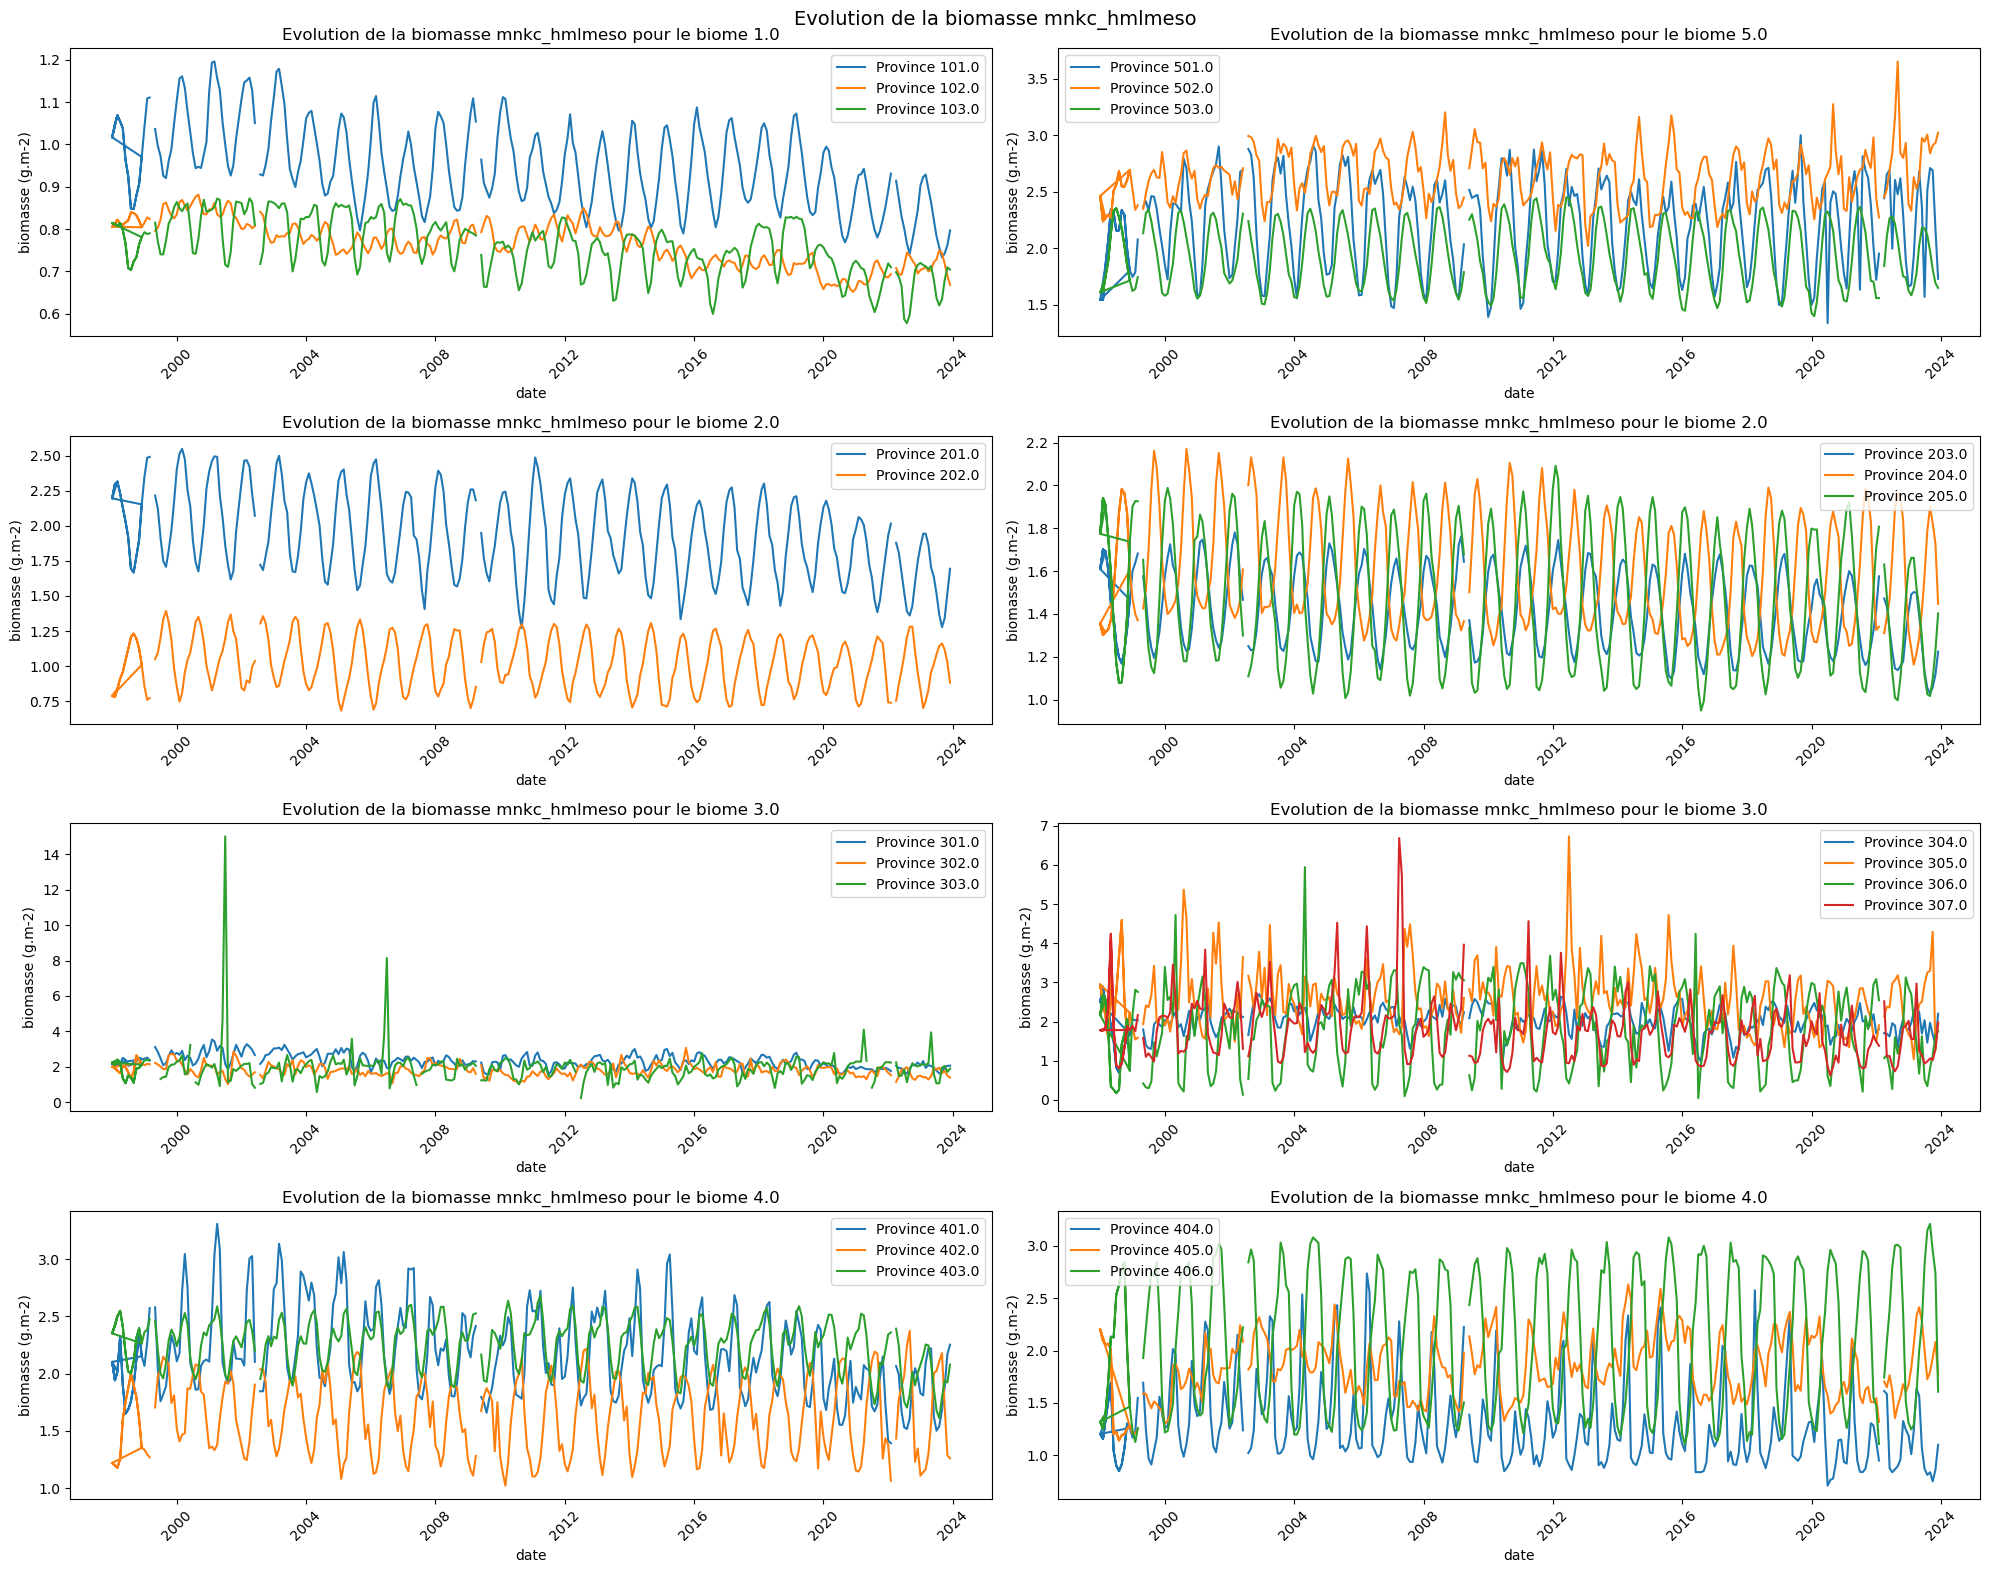

In [26]:
plt.figure(figsize=(20, 16))

subplot_idx = 1


for biome in biome_selected:
    df_by_biome= df_mnkc[df_mnkc["Biome"] == biome]
    provinces= list(df_by_biome["prov"].unique())

    if len(provinces) <=3:
        groups = [provinces]
    else:
        middle = len(provinces)//2
        groups = [provinces[:middle], provinces[middle:]]

    for group in groups:
        plt.subplot(4, 2, subplot_idx)

        for prov_id in group:
            df_prov= df_by_biome[df_by_biome['prov'] == prov_id]
            plt.plot(df_prov.index, df_prov[biomass_selected], label=f"Province {prov_id}")
            
        plt.title(f"Evolution de la biomasse {biomass_selected} pour le biome {biome}")
        plt.xlabel("date")
        plt.ylabel("biomasse (g.m-2)")
        plt.legend()
        plt.xticks(rotation=45)

        subplot_idx +=1

plt.suptitle(f"Evolution de la biomasse {biomass_selected}", fontsize=14)
plt.tight_layout()
plt.show()

